# **Lab Assignment 2**

## 1. Import required libraries and load the load_Wine Dataset from scikit-learn [0 Marks]

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_wine

wine = load_wine()
x = wine.data       # feature variables
y = wine.target     # target variable
df = pd.DataFrame(x, columns=wine.feature_names)
df['Class'] = y
print("Shape of the data frame:", df.shape)
df.head()

Shape of the data frame: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 2. Exploratory Data Analysis [2 Marks]

Perform the following analyses.

(a) Check
- Missing values
- Data types

(b) Visualize Class distribution

(c) Draw Correlation Heatmap

(d) Plot Histograms

(e) Generate Pair Plot

(f) Write your observations for each visualization.

In [3]:
print('COUNT OF MISSING VALUES')
df.isnull().sum()

COUNT OF MISSING VALUES


alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
Class                           0
dtype: int64

In [4]:
print('DATA TYPE OF EACH COLUMN')
print(df.dtypes)

DATA TYPE OF EACH COLUMN
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
Class                             int64
dtype: object


CLASS DISTRIBUTION
Class
1    71
0    59
2    48
Name: count, dtype: int64


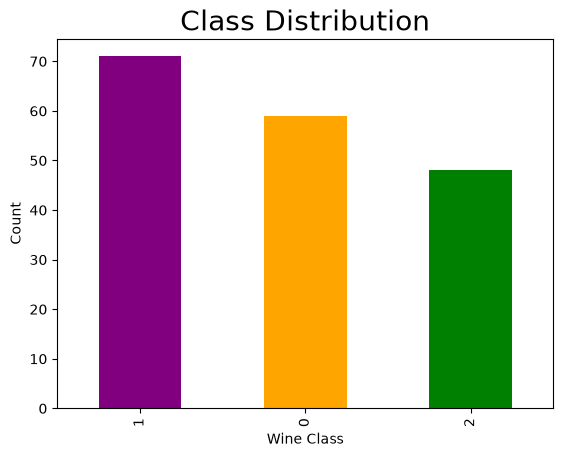

In [5]:
print('CLASS DISTRIBUTION')
class_labels = df['Class'].value_counts()
print(class_labels)

class_labels.plot(kind='bar', color=['purple', 'orange', 'green'])
plt.title('Class Distribution', fontsize=20)
plt.xlabel('Wine Class')
plt.ylabel('Count')
plt.savefig('plots/class_distribution.png')

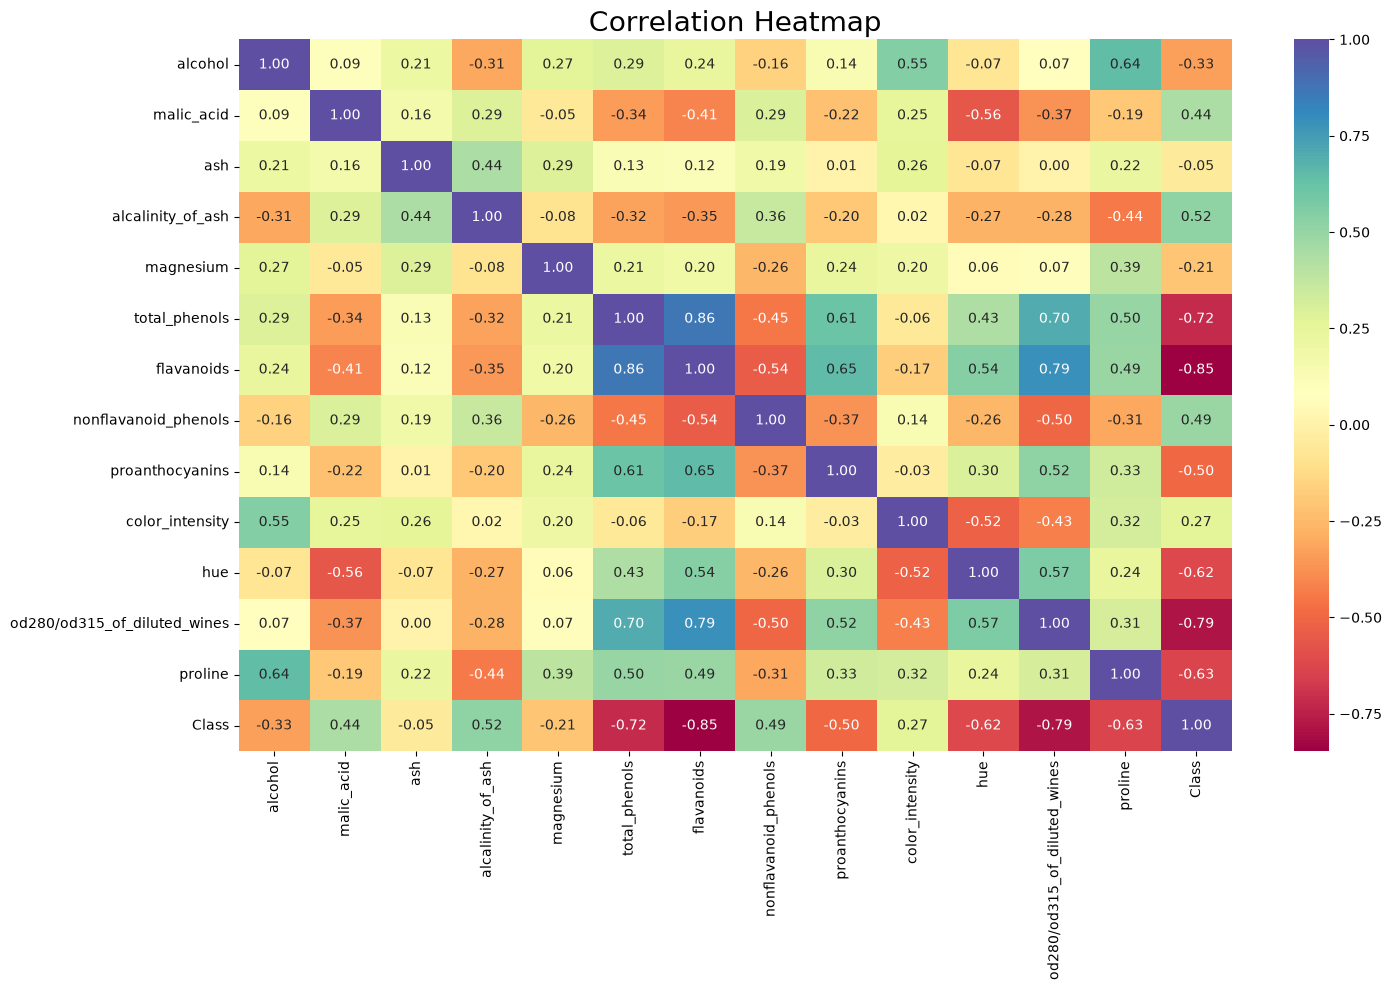

In [6]:
# Correlation Heatmap
plt.figure(figsize=(15, 10))
plt.title("Correlation Heatmap", fontsize=20)
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='Spectral')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png')

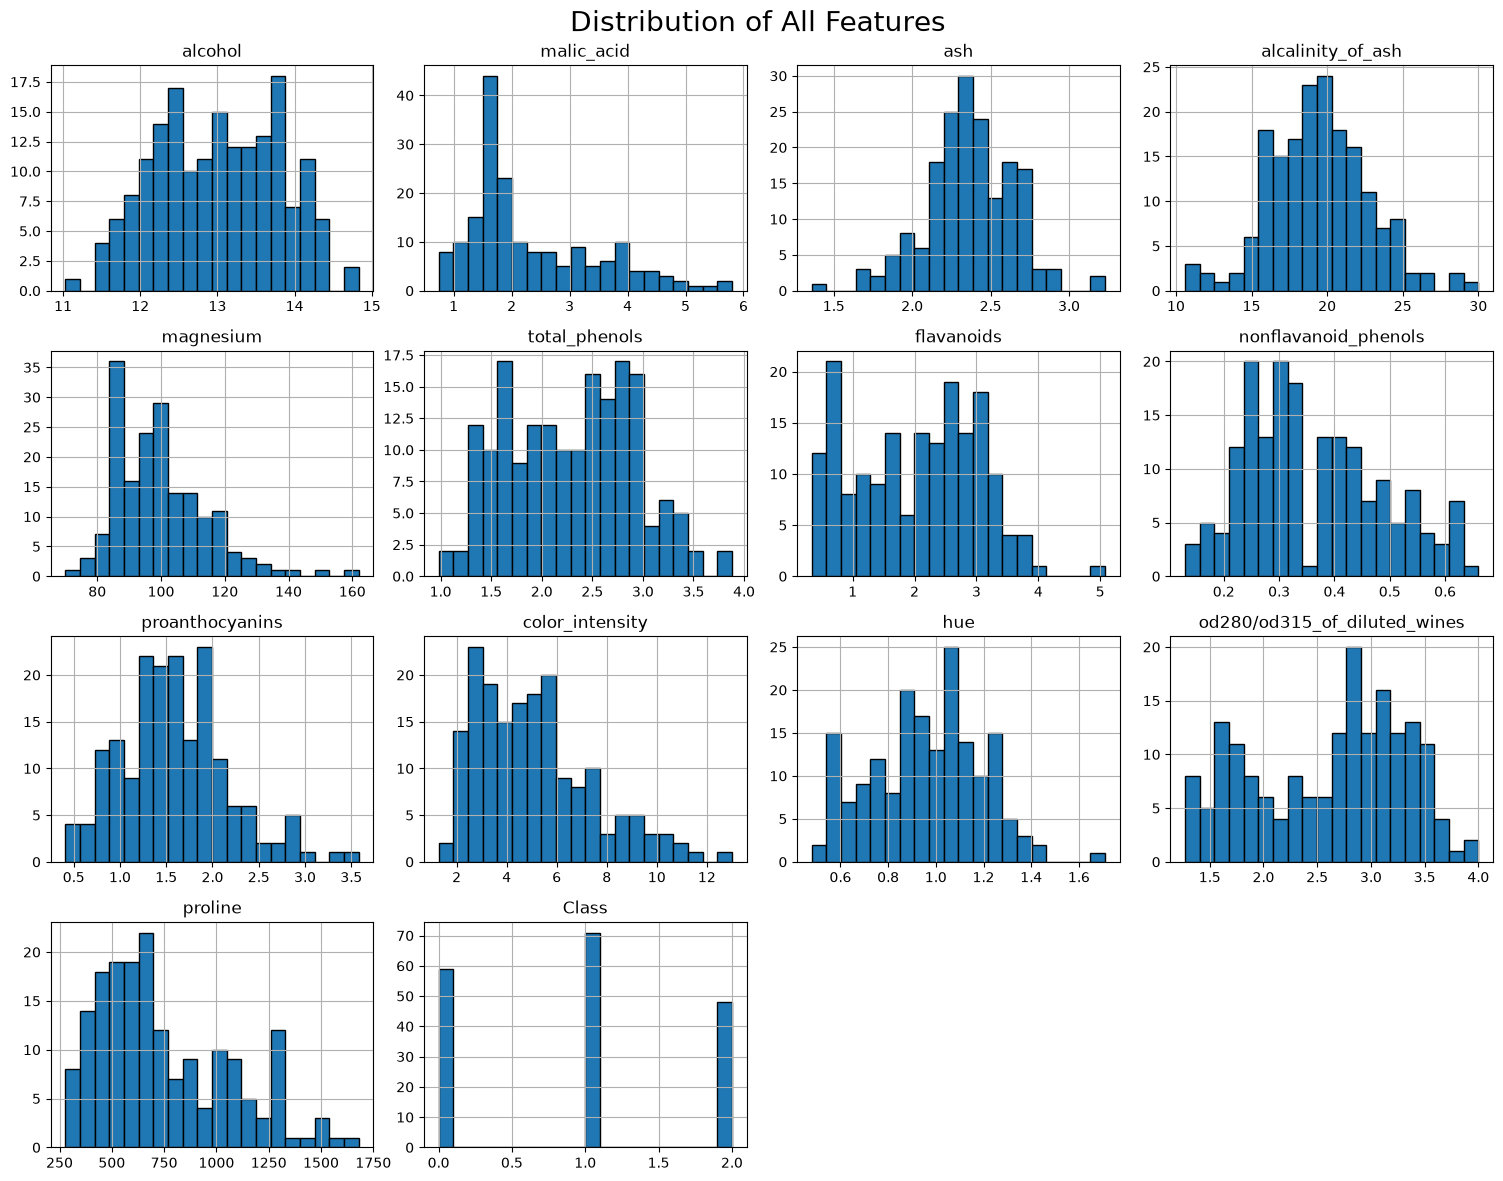

In [7]:
# Histograms
df.hist(figsize=(15, 12), bins=20, edgecolor='Black')
plt.suptitle('Distribution of All Features', fontsize=20)
plt.tight_layout()
plt.savefig('plots/histogram_all_features.png')

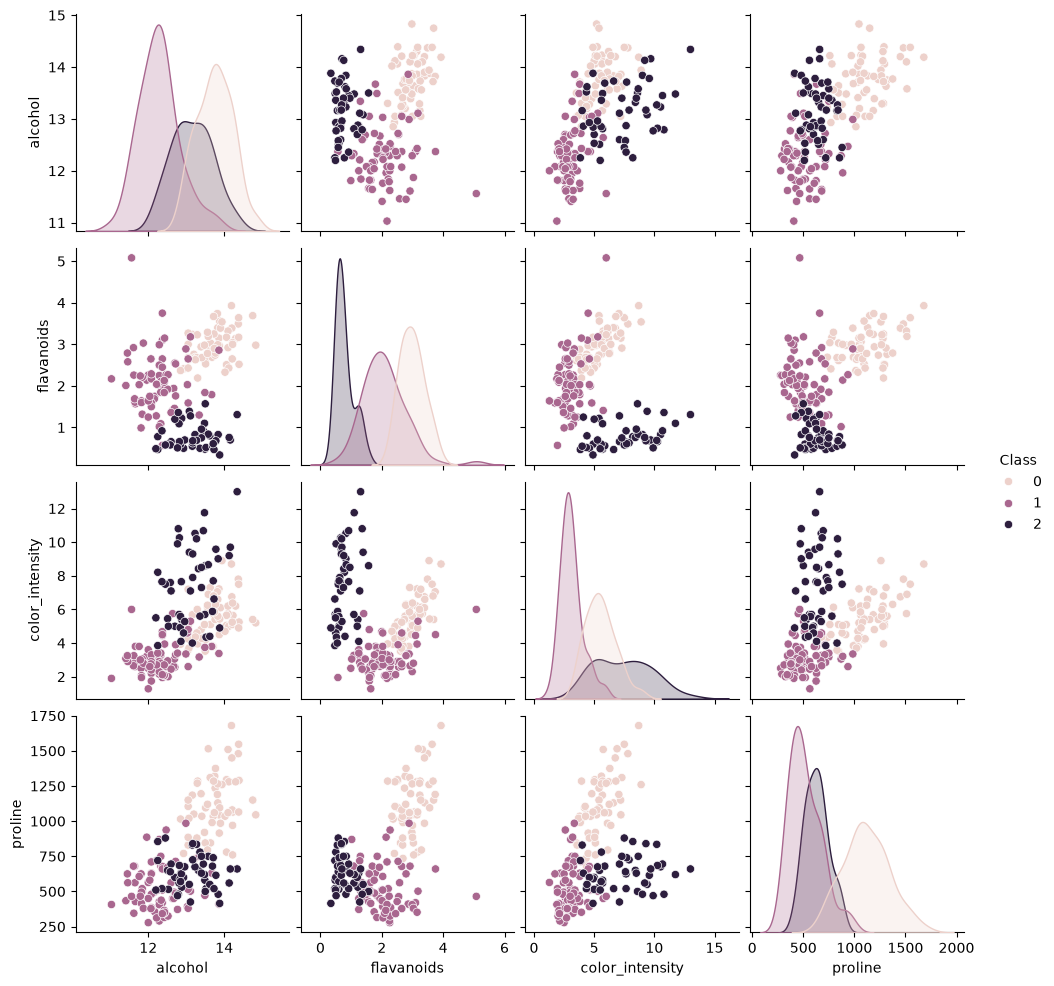

In [8]:
# Pair plot of selected features
selected_features = ['alcohol', 'flavanoids', 'color_intensity', 'proline']
sns.pairplot(df, vars=selected_features, hue='Class')
plt.savefig('plots/pair_plot_selected_features.png')

***EDA Observations***

| **Analysis** | **Observation** |
|---|---|
| Missing Values | No missing values are present in the dataset. |
| Data Types | All features are numerical; target is an integer representing 3 classes (0 to 2). |
| Class Distribution | Class 1 has the most samples (71), followed by Class 0 (59) and Class 2 (48). |
| Correlation | Highest +ve: flavanoids and total_phenols (0.86), Highest -ve: flavanoids and Class (-0.85). |
| Histograms | Features have different scales and varying distributions. Many distributions are skewed. |
| Pair Plot | Several feature combinations involving flavanoids show less overlap between the classes. |

## 3. Perform Feature Scaling and One-Hot Encoding [1 Marks]

- Use StandardScaler

- Compare Original features with Scaled features

- Display Mean , Standard deviation

- Convert the target labels into one-hot vectors.

- Display the encoded labels.

In [10]:
# Feature scaling using Standard Scaler
from sklearn.preprocessing import StandardScaler

x = df.drop('Class', axis=1)    # drop the Class column
y = df['Class']                 # store the target Class

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)  # returns numpy array

# convert back into a data frame
x_scaled = pd.DataFrame(x_scaled, columns=x.columns)    
x_scaled.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


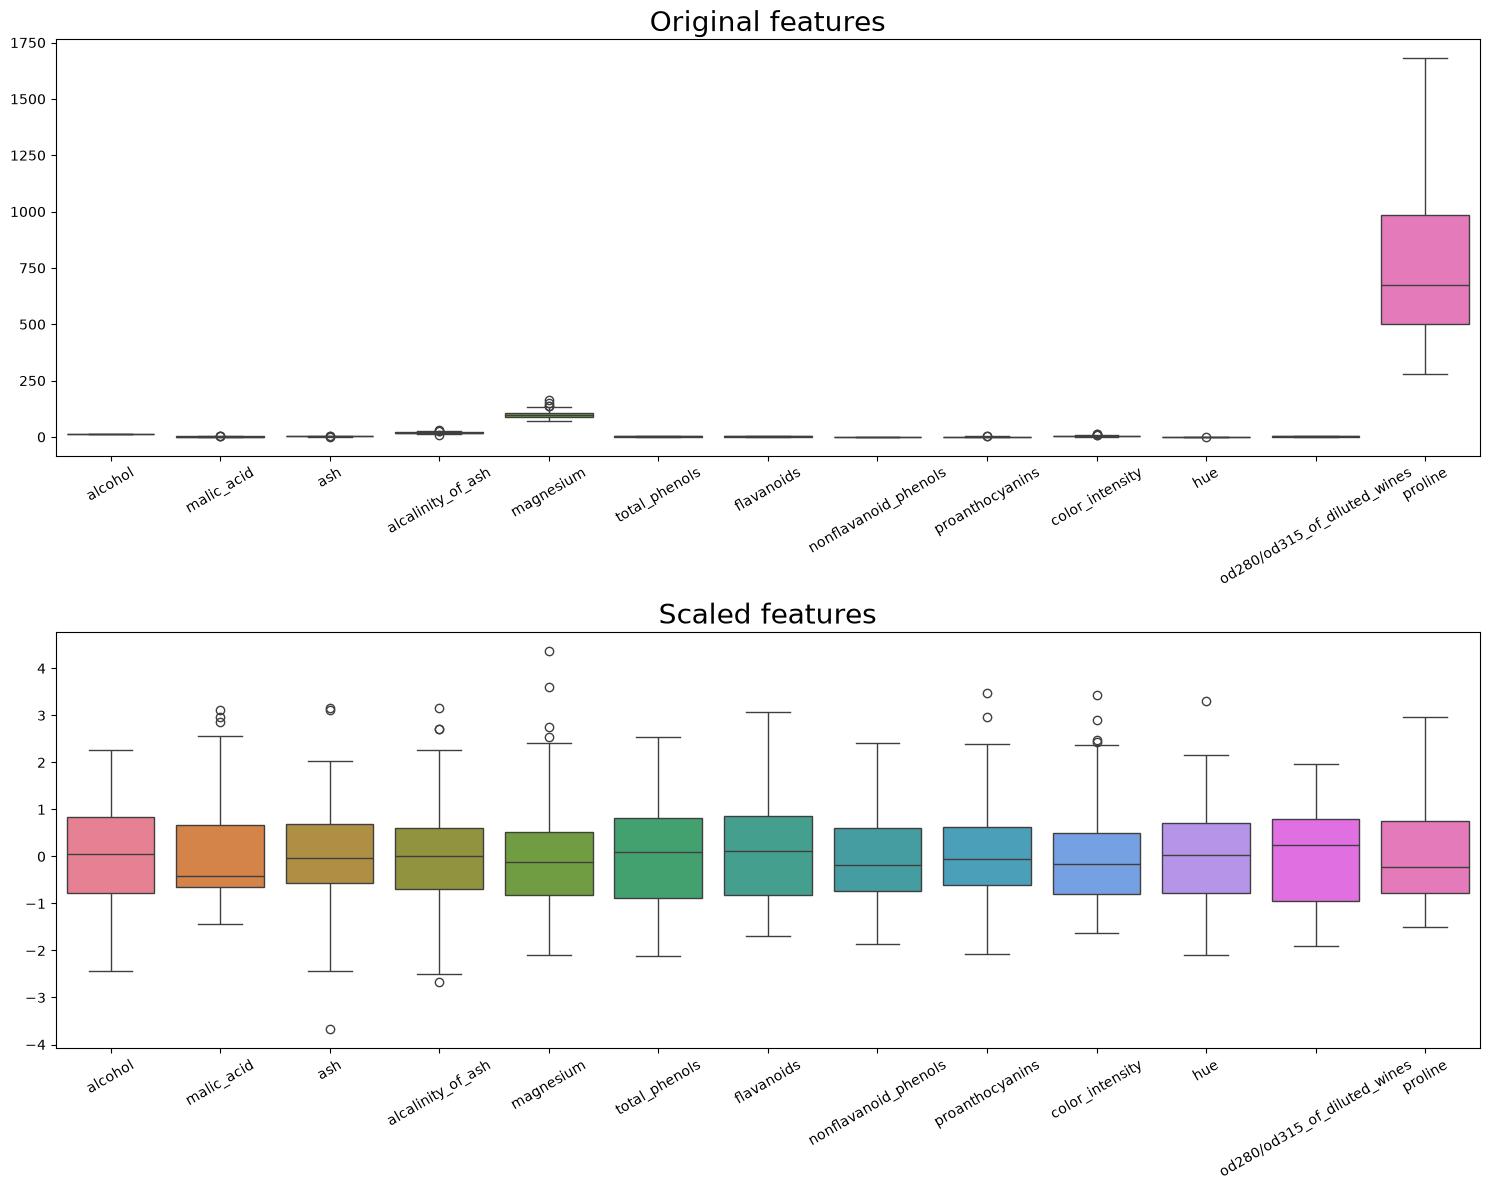

In [11]:
# Original vs scaled features (Box Plot)
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# original features
sns.boxplot(data=x, ax=axes[0])
axes[0].set_title('Original features', fontsize=20)
axes[0].tick_params(axis='x', rotation=30)

# scaled features
sns.boxplot(data=x_scaled, ax=axes[1])
axes[1].set_title('Scaled features', fontsize=20)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('plots/original_vs_scaled.png')

In [12]:
# Mean & Standard Deviation
stats = pd.DataFrame({
    'Original mean': x.mean(),
    'Original std. deviation': x.std(),
    'Scaled mean': x_scaled.mean(),
    'Scaled std. deviation': x_scaled.std()
})
display(stats)

,Original mean,Original std. deviation,Scaled mean,Scaled std. deviation
alcohol,13.000618,0.811827,-8.382808e-16,1.002821
malic_acid,2.336348,1.117146,-1.197544e-16,1.002821
ash,2.366517,0.274344,-8.370333e-16,1.002821
alcalinity_of_ash,19.494944,3.339564,-3.991813e-17,1.002821
magnesium,99.741573,14.282484,-3.991813e-17,1.002821
total_phenols,2.295112,0.625851,0.000000e+00,1.002821
flavanoids,2.029270,0.998859,-3.991813e-16,1.002821
nonflavanoid_phenols,0.361854,0.124453,3.592632e-16,1.002821
proanthocyanins,1.590899,0.572359,-1.197544e-16,1.002821
color_intensity,5.058090,2.318286,2.494883e-17,1.002821


In [13]:
# One-hot encoding of Target Class
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)                # don't return sparse matrix
y_encoded = encoder.fit_transform(y.values.reshape(-1, 1))  # reshape into single-column matrix

# convert back into a data frame
y_encoded = pd.DataFrame(y_encoded, columns=encoder.get_feature_names_out(['Class']))

# display the encoded labels
display(y_encoded)

,Class_0,Class_1,Class_2
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0
...,...,...,...
173,0.0,0.0,1.0
174,0.0,0.0,1.0
175,0.0,0.0,1.0
176,0.0,0.0,1.0


## 5. Split the data into training, validation, and test sets (70%-15%-15%). [Marks 1]

In [14]:
from sklearn.model_selection import train_test_split

# Train : Val : Test = 70 : 15 : 15
x_train, x_temp, y_train, y_temp = train_test_split(x_scaled, y_encoded, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

print(f'Shape of Training data: X = {x_train.shape} Y = {y_train.shape}')
print(f'Shape of Validation data: X = {x_val.shape} Y = {y_val.shape}')
print(f'Shape of Testing data: X = {x_test.shape} Y = {y_test.shape}')

Shape of Training data: X = (124, 13) Y = (124, 3)
Shape of Validation data: X = (27, 13) Y = (27, 3)
Shape of Testing data: X = (27, 13) Y = (27, 3)


## 6. Implement Elastic-Net Softmax Regression from Scratch [6 Marks]

In this step, you will implement an **Elastic-Net Regularized Softmax Regression** model from scratch using **Gradient Descent**. **Do not use any machine learning library** (e.g., Scikit-learn, TensorFlow, or PyTorch) for model training.

Your implementation must include the following components.

---

### (a) Softmax Function

Implement the **Softmax activation function** to convert the raw logits into class probabilities.

The Softmax function should satisfy the following properties:

- The probability of each class lies between **0 and 1**.
- The sum of probabilities for each sample should be **equal to 1**.

---

### (b) Cross-Entropy Loss

Implement the **Multiclass Cross-Entropy Loss** to measure the difference between the predicted probabilities and the true class labels.

Your implementation should compute the average loss over all training samples.

---

### (c) L1 Regularization (Lasso)

Extend the loss function by adding an **L1 Regularization** term.

The L1 penalty is defined as

$$
L_{L1}=\lambda_1\sum_{i,j}|W_{ij}|
$$

where

- $W$ is the weight matrix.
- $\lambda_1$ is the L1 regularization parameter.

---

### (d) L2 Regularization (Ridge)

Further extend the loss function by adding an **L2 Regularization** term.

The L2 penalty is defined as

$$
L_{L2}=\frac{\lambda_2}{2}\sum_{i,j}W_{ij}^{2}
$$

where

- $W$ is the weight matrix.
- $\lambda_2$ is the L2 regularization parameter.

---

### (e) Gradient of L1 Regularization

Implement the gradient of the L1 regularization term.

The gradient is given by

$$
\frac{\partial |W|}{\partial W}=\operatorname{sign}(W)
$$

---

### (f) Gradient of L2 Regularization

Implement the gradient of the L2 regularization term.

The gradient is given by

$$
\frac{\partial}{\partial W}\left(\frac{\lambda_2}{2}\|W\|_2^2\right)=\lambda_2W
$$

---

### (g) Gradient Descent Optimization

Implement the complete **Gradient Descent** algorithm for training the model.

During each training epoch, your implementation must perform the following steps:

1. Compute the logits.
2. Apply the Softmax function.
3. Compute the Cross-Entropy Loss.
4. Add the L1 and L2 regularization terms.
5. Compute the gradients of the weights and bias.
6. Update the model parameters using Gradient Descent.
7. Store the **Training Loss**.
8. Compute and store the **Validation Loss**.

---

### Expected Outputs

After completing this step, your implementation should:

- Successfully train an Elastic-Net Softmax Regression model.
- Store the **training loss** after every epoch.
- Store the **validation loss** after every epoch.
- Learn the optimal weight matrix and bias vector.

> **Note**
>
> - You must implement the complete algorithm **from scratch**.
> - Do **not** use any built-in machine learning library for model training.
> - Only **NumPy** may be used for numerical computations.

In [15]:
class ElasticNetSoftmaxRegression:
    def __init__(self, learning_rate, n_epochs, l1, l2):
        """
        Hyperparameters
        """
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs    # no. of iterations
        self.lambda1 = l1           # L1 loss
        self.lambda2 = l2           # L2 loss
    
    def softmax(self, z):
        """
        Softmax function
        """
        z = z - np.max(z, axis=1, keepdims=True)        # prevent overflow   
        exp_z = np.exp(z)                               # exponentiation
        exp_sum = np.sum(exp_z, axis=1, keepdims=True)  # sum of exponentiation
        return exp_z / exp_sum
    
    def compute_loss(self, y_true, y_pred):
        """
        Loss Function = mean Cross-Entropy loss + lambda1 * L1 loss + lambda2 / 2 * L2 loss
        """
        epsilon = 1e-15
        sample_errors = -np.sum(
            y_true * np.log(y_pred + epsilon), axis = 1)    # add epsilon to prevent log(0) computation
        mean_ce_error = np.mean(sample_errors)              
        
        l1_loss = self.lambda1 * np.sum(np.abs(self.w))     # sum of absolute weights
        l2_loss = self.lambda2 / 2 * np.sum(self.w ** 2)    # sum of squared weights
        
        total_loss = mean_ce_error + l1_loss + l2_loss
        return total_loss
    
    def fit(self, x_train, y_train, x_val, y_val):
        """
        Train the model
        """
        n_samples, n_features = x_train.shape
        n_classes = y_train.shape[1]
        
        # initialize the model weights & bias
        self.w = np.zeros((n_features, n_classes))
        self.b = np.zeros((1, n_classes))
        
        # loss storage
        self.train_loss = []
        self.val_loss = []
        
        # Gradient descent optimization
        for epoch in range(self.n_epochs):
            # forward pass
            logits = x_train @ self.w + self.b              # compute the logits 
            y_pred = self.softmax(logits)                   # apply softmax 
            
            # compute the loss function
            train_loss = self.compute_loss(y_train, y_pred) 
            
            # compute gradients
            dz = (y_pred - y_train) / n_samples             
            dw = x_train.T @ dz                             # weight gradient of cross entropy loss
            dw += self.lambda1 * np.sign(self.w)            # add gradient of L1
            dw += self.lambda2 * self.w                     # add gradient of L2
            db = np.sum(dz, axis=0, keepdims=True)          # bias gradient
            
            # update model parameters
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
            
            # store training loss
            self.train_loss.append(train_loss)
            
            # store validation loss
            val_pred = self.softmax(x_val @ self.w + self.b)
            self.val_loss.append(self.compute_loss(y_val, val_pred))

    def predict_probabilities(self, x):
        """
        Compute the probability vectors
        """
        logits = x @ self.w + self.b
        return self.softmax(logits)
    
    def predict_class(self, x):
        """
        Return the predicted class labels
        """
        return np.argmax(self.predict_probabilities(x), axis=1)
    

## 7. Train the Model [1 Mark]

Train the **Elastic-Net Softmax Regression** model using the **Gradient Descent** algorithm.

---

## Training Configuration

Train the model for **1000 epochs**.

Select appropriate values for the following hyperparameters:

- **Learning Rate ($\alpha$)**
- **L1 Regularization Parameter ($\lambda_1$)**
- **L2 Regularization Parameter ($\lambda_2$)**

You may experiment with different values of these hyperparameters to achieve better model performance.

In [16]:
# convert data frames into numpy arrays
x_train = x_train.to_numpy()
y_train = y_train.to_numpy()
x_val = x_val.to_numpy()
y_val = y_val.to_numpy()
x_test = x_test.to_numpy()
y_test = y_test.to_numpy()

# train the model
ens_regressor = ElasticNetSoftmaxRegression(learning_rate=0.01, n_epochs=1000, l1=0.01, l2=0.01)
ens_regressor.fit(x_train, y_train, x_val, y_val)

## 8. Plot Learning Curve [1 Mark]

- Plot Training Loss and Validation Loss

- Discuss Underfitting and Overfitting

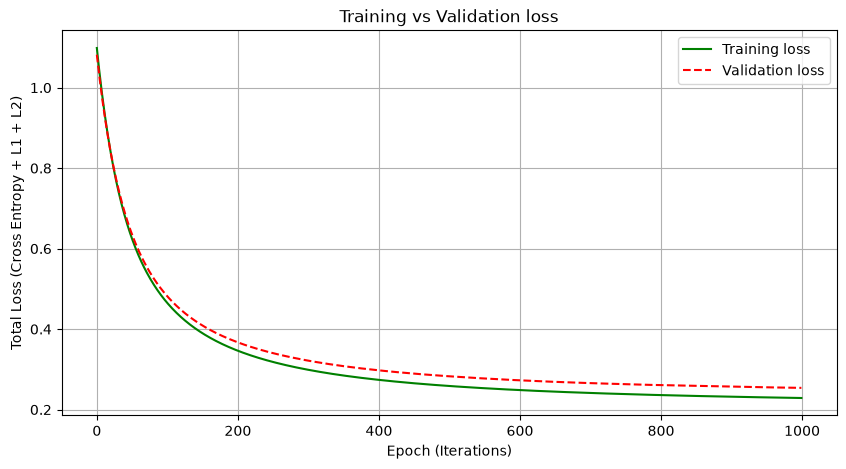

In [17]:
# Learning curve
plt.figure(figsize=(10, 5))
sns.lineplot(ens_regressor.train_loss, label='Training loss', linestyle='-', color='green')
sns.lineplot(ens_regressor.val_loss, label='Validation loss', linestyle='--', color='red')

plt.title('Training vs Validation loss')
plt.xlabel('Epoch (Iterations)')
plt.ylabel('Total Loss (Cross Entropy + L1 + L2)')
plt.grid(True)
plt.savefig('plots/training_vs_validation.png')

**Remark on Overfitting and Underfitting**
- Both training and validation losses decrease steadily, indicating ***no significant underfitting***.
- The losses remain close, and validation loss continues to decrease, indicating ***no significant overfitting***.

## 9. Predict on test set [1 Mark]
 - display actual and predicted class

In [18]:
# Predict classes for test data
y_pred = ens_regressor.predict_class(x_test)
y_true = np.argmax(y_test, axis=1)

# Display results
results = pd.DataFrame({
    'Actual class': y_true,
    'Predicted class': y_pred
})
display(results)

,Actual class,Predicted class
0,1,1
1,0,0
2,2,2
3,0,0
4,2,2
5,0,0
6,1,1
7,0,0
8,0,0
9,2,2


## 10. Evaluate the Model [1 Mark]

- compute Accuracy, precision, recall, f1_score

In [19]:
# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_true, y_pred):
    """
    Calculate the scores to evaluate model predictions
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    return accuracy, precision, recall, f1


In [20]:
accuracy, precision, recall, f1 = evaluate_model(y_true, y_pred)

metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})
display(metrics)

,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0


## 11. Plot the Confusion matrix, Classification report and interpret the results. [1 Marks]

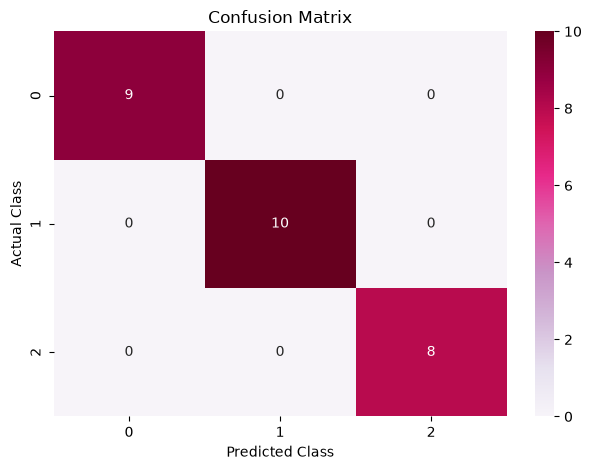

In [21]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, cmap='PuRd')

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('plots/confusion_matrix.png')

In [22]:
# Classification report
from sklearn.metrics import classification_report

cr = classification_report(y_true, y_pred, labels=[0, 1, 2], target_names=['Class 0', 'Class 1', 'Class 2'])
print(cr)

              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00         9
     Class 1       1.00      1.00      1.00        10
     Class 2       1.00      1.00      1.00         8

    accuracy                           1.00        27
   macro avg       1.00      1.00      1.00        27
weighted avg       1.00      1.00      1.00        27



**Interpretation of the Results**
- All the test samples were correctly classified, with ***no misclassifications*** between the three classes.
- Precision, recall, and F1-score are ***1.0000*** for all three classes, indicating perfect classification.

Overall, the `from-scratch implementation of Elastic-Net Softmax Regression` model performs very well on this test set, with no classification errors.

## 12. Perform the Sklearn Implementation and Compare the both model. [1 Marks]

In [23]:
from sklearn.linear_model import LogisticRegression

sk_ens_regressor = LogisticRegression(
    # penalty='elasticnet',   # support both L1 and L1 penalties (DEPRECATED)
    solver='saga',          # only 'saga' solver supports 'elasticnet'
    C=500,                  # C = 1 / lambda
    l1_ratio=0.5,           # ratio of lambda 1 in lambda
    max_iter=1000,
    random_state=42
)
sk_ens_regressor.fit(x_train, np.argmax(y_train, axis=1))   # train
sk_y_pred = sk_ens_regressor.predict(x_test)                # predict

c:\Users\SWARNOTAJ\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [24]:
# compare prediction results
result_comparison = pd.DataFrame({
    'Actual values': y_true,
    'Predicted values (From-scratch)': y_pred,
    'Predicted values (Sklearn)': sk_y_pred
})
display(result_comparison)

,Actual values,Predicted values (From-scratch),Predicted values (Sklearn)
0,1,1,1
1,0,0,0
2,2,2,2
3,0,0,0
4,2,2,2
5,0,0,0
6,1,1,1
7,0,0,0
8,0,0,0
9,2,2,2


In [25]:
# compare performance metrics
sk_accuracy, sk_precision, sk_recall, sk_f1 = evaluate_model(y_true, sk_y_pred)

metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score (From-scratch)': [accuracy, precision, recall, f1],
    'Score (Sklearn)': [sk_accuracy, sk_precision, sk_recall, sk_f1]
})
display(metrics)

,Metric,Score (From-scratch),Score (Sklearn)
0,Accuracy,1.0,1.0
1,Precision,1.0,1.0
2,Recall,1.0,1.0
3,F1 Score,1.0,1.0


***Interpretation of the Comparison***

Both the from-scratch and Scikit-learn models achieved similar performance across accuracy, precision, recall, and F1-score. This indicates that the `from-scratch implementation` **correctly reproduces the behaviour of Elastic-Net Softmax Regression**.

## 13: Effect of Regularization [3 Marks]

In this section, analyze the effect of different regularization techniques on the performance of the **Softmax Regression** model.

Train the model using the following three configurations and compare the results.

---

### Case 1: No Regularization

Train the model without any regularization.

**Hyperparameters**

- L1 Regularization ($\lambda_1$) = **0**
- L2 Regularization ($\lambda_2$) = **0**

This serves as the baseline model.

---

### Case 2: L2 Regularization (Ridge)

Train the model using **only L2 Regularization**.

**Hyperparameters**

- L1 Regularization ($\lambda_1$) = **0**
- L2 Regularization ($\lambda_2$) = **0.01**

Observe how L2 regularization affects the model performance and the learning curves.

---

### Case 3: Elastic-Net Regularization

Train the model using **both L1 and L2 Regularization**.

**Hyperparameters**

- L1 Regularization ($\lambda_1$) = **0.01**
- L2 Regularization ($\lambda_2$) = **0.01**

Observe the combined effect of L1 and L2 regularization on the model.

---

### Compare the Following Performance Metrics

For each configuration, compute and compare:

- Accuracy
- Precision
- Recall
- F1-Score
- Training Loss
- Validation Loss

Present your results in the following table.

| Model | Accuracy | Precision | Recall | F1-Score | Training Loss | Validation Loss |
|--------|---------:|----------:|--------:|---------:|--------------:|----------------:|
| No Regularization | | | | | | |
| L2 Regularization | | | | | | |
| Elastic-Net Regularization | | | | | | |

---



In [26]:
# Case-1: No regularization
no_reg = ElasticNetSoftmaxRegression(learning_rate=0.01, n_epochs=1000, l1=0, l2=0)
no_reg.fit(x_train, y_train, x_val, y_val)
no_y_pred = no_reg.predict_class(x_test)
 
# Case-2: L2 (Ridge) regularization
l2_reg = ElasticNetSoftmaxRegression(learning_rate=0.01, n_epochs=1000, l1=0, l2=0.01)
l2_reg.fit(x_train, y_train, x_val, y_val)
l2_y_pred = l2_reg.predict_class(x_test)

# Case-3: Elastic-Net regularization
en_reg = ElasticNetSoftmaxRegression(learning_rate=0.01, n_epochs=1000, l1=0.01, l2=0.01)
en_reg.fit(x_train, y_train, x_val, y_val)
en_y_pred = en_reg.predict_class(x_test)

In [27]:
# Compare the performance metrics
no_accuracy, no_precision, no_recall, no_f1 = evaluate_model(y_true, no_y_pred)
l2_accuracy, l2_precision, l2_recall, l2_f1 = evaluate_model(y_true, l2_y_pred)
en_accuracy, en_precision, en_recall, en_f1 = evaluate_model(y_true, en_y_pred)

metrics_comparison = pd.DataFrame({
    'Model': ['No Regularization', 'L2 Regularization', 'Elastic-Net Regularization'],
    'Accuracy': [no_accuracy, l2_accuracy, en_accuracy],
    'Precision': [no_precision, l2_precision, en_precision],
    'Recall': [no_recall, l2_recall, en_recall],
    'F1-Score': [no_f1, l2_f1, en_f1],
    'Training Loss': [no_reg.train_loss[-1], l2_reg.train_loss[-1], en_reg.train_loss[-1]],
    'Validation Loss': [no_reg.val_loss[-1], l2_reg.val_loss[-1], en_reg.val_loss[-1]]
})
display(metrics_comparison)

,Model,Accuracy,Precision,Recall,F1-Score,Training Loss,Validation Loss
0,No Regularization,1.0,1.0,1.0,1.0,0.094887,0.128399
1,L2 Regularization,1.0,1.0,1.0,1.0,0.123767,0.156394
2,Elastic-Net Regularization,1.0,1.0,1.0,1.0,0.228816,0.253979


### 14. Analysis [1 Marks]

Based on the experimental results, answer the following questions.

1. Which regularization technique achieved the highest classification accuracy?

2. How did L2 regularization affect the training and validation losses compared to the model without regularization?

3. What impact did adding L1 regularization have on the overall model performance?

4. Which model showed the best generalization performance on the validation and test datasets?

5. Which regularization technique would you recommend for this dataset? Justify your answer using the obtained results.

***Answers***

1. All three models achieved the same **100% accuracy**. Therefore, no regularization technique had an accuracy advantage.
2. `L2 regularization` increased the training loss from **0.0949 to 0.1238** and the validation loss from **0.1284 to 0.1564**.
3. `Adding L1 regularization` further increased the losses. The Elastic-Net model had a training loss of **0.2288** and validation loss of **0.2540**, while the classification metrics remained at **100%**.
4.  The `No Regularization` model showed the best generalization performance because it had the lowest validation loss (**0.1284**) while achieving **100% accuracy, precision, recall, and F1-score** on the test dataset.
5. `No Regularization` is recommended for this dataset. All three models achieved identical test performance, while the unregularized model had the lowest training and validation losses. Therefore, **regularization did not provide any observable performance benefit** for this dataset.

---
End of the Assignment